## Bivariate Analysis

### 4. Bivariate Analysis

This notebook explores the relationship between each feature and the target variable (`Churn`).

The analysis is divided into:

- Numerical Features vs Churn
- Categorical Features vs Churn

The objective is to identify patterns, trends, and feature importance before feature engineering and model development.

In [1]:
# Section 1 — Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")


# Section 2 — Load Dataset
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [2]:
# Numerical Features

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


# Categorical Features

categorical_features = df.select_dtypes(
    include="object"
).columns.tolist()


print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [3]:
categorical_features.remove("customerID")

In [4]:
summary = pd.DataFrame({

    "Data Type": df.dtypes,

    "Missing Values": df.isnull().sum(),

    "Unique Values": df.nunique()

})

summary

,Data Type,Missing Values,Unique Values
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


##  Part - A: Numerical Features vs Churn

This section examines how numerical features vary across different churn groups.

For each numerical feature, we compare descriptive statistics and visualize the distribution across customers who churned and those who remained.

### Helper Function 1: Group-wise Summary Statistics

This helper function compares the descriptive statistics of a numerical feature across different churn groups.

The statistics are calculated separately for customers who churned and those who did not, making it easier to identify differences between the two groups.

In [6]:
# Helper function - 1

def display_group_statistics(df, column, target="Churn"):
    """
    Display summary statistics of a numerical feature
    grouped by the target variable.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Numerical feature name.

    target : str, default="Churn"
        Target variable.
    """

    group_statistics = (
        df
        .groupby(target)[column]
        .describe()
        .round(2)
    )

    display(group_statistics)

### Helper Function 2: Boxplot by Target

This helper function visualizes the distribution of a numerical feature across different churn groups using a boxplot.

The boxplot helps compare the median, spread, and potential outliers between customers who churned and those who did not.

In [ ]:
# Helper function - 2

def plot_boxplot_by_target(df, column, target="Churn"):
    """
    Plot the distribution of a numerical feature
    across target classes using a boxplot.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Numerical feature name.

    target : str, default="Churn"
        Target variable.
    """

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=target,
        y=column,
        palette="Set2"
    )

    plt.title(
        f"{column} vs {target}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(target)
    plt.ylabel(column)

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    plt.show()

### Master Function: Numerical Feature vs Target Analysis

This function performs a complete bivariate analysis of a numerical feature with respect to the target variable.

For each numerical feature, it performs the following analyses:

1. Group-wise Summary Statistics
2. Boxplot by Target

This modular workflow provides both statistical and visual comparisons between customers who churned and those who did not.

In [7]:
# Master Function for Numerical Feature v/s Target Analysis 

def analyze_numerical_vs_target(df, column, target="Churn"):
    """
    Perform a complete bivariate analysis of a numerical
    feature against the target variable.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Numerical feature name.

    target : str, default="Churn"
        Target variable.
    """

    if column not in df.columns:
        raise ValueError(f"'{column}' is not a valid column in the DataFrame.")

    if target not in df.columns:
        raise ValueError(f"'{target}' is not a valid column in the DataFrame.")

    if not pd.api.types.is_numeric_dtype(df[column]):
        raise TypeError(f"'{column}' is not a numerical feature.")

    print("\n")
    print("=" * 80)
    print(f"NUMERICAL FEATURE VS {target.upper()} : {column.upper()}")
    print("=" * 80)

    display_group_statistics(df, column, target)
    print("\n")

    plot_boxplot_by_target(df, column, target)

    print("\n")
    print("=" * 80)
    print("Analysis Completed")
    print("=" * 80)



NUMERICAL FEATURE VS CHURN : TENURE


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


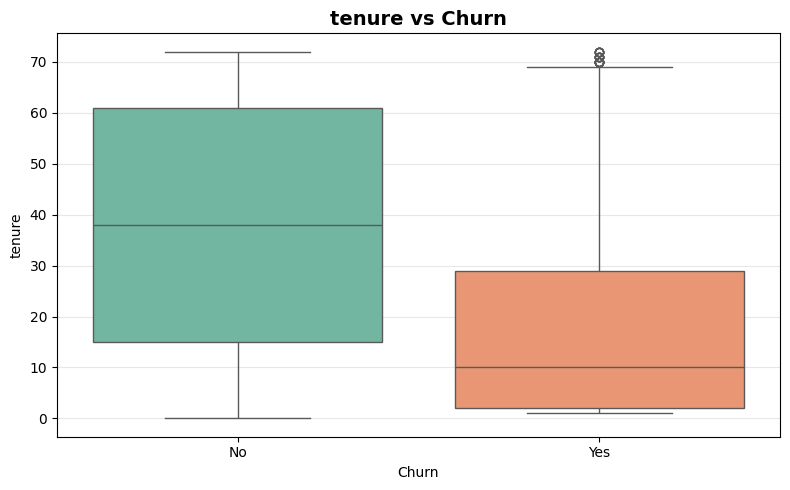



Analysis Completed


In [8]:
analyze_numerical_vs_target(df, "tenure")



NUMERICAL FEATURE VS CHURN : SENIORCITIZEN


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,0.13,0.33,0.0,0.0,0.0,0.0,1.0
Yes,1869.0,0.25,0.44,0.0,0.0,0.0,1.0,1.0


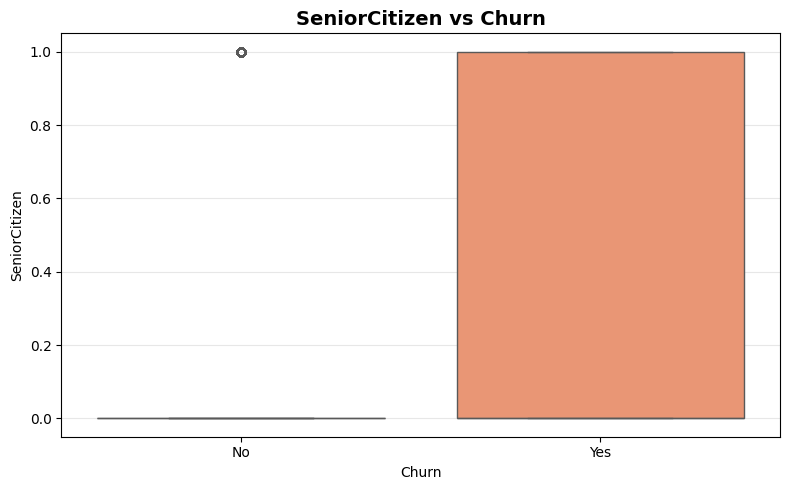



Analysis Completed


NUMERICAL FEATURE VS CHURN : TENURE


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


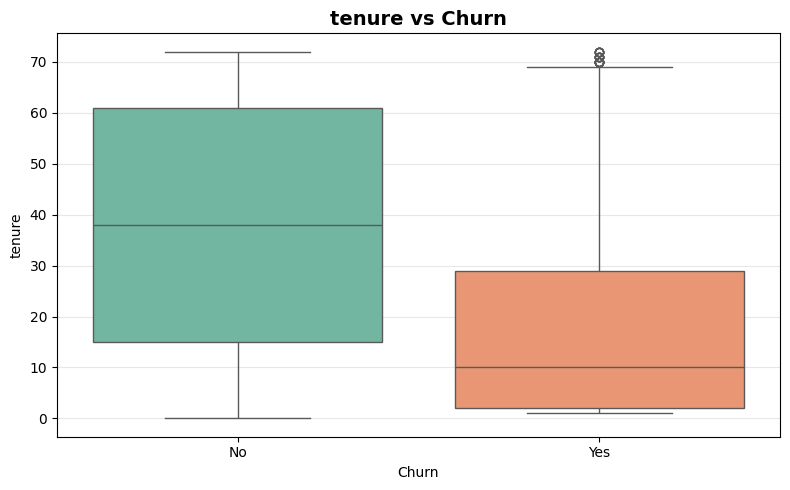



Analysis Completed


NUMERICAL FEATURE VS CHURN : MONTHLYCHARGES


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


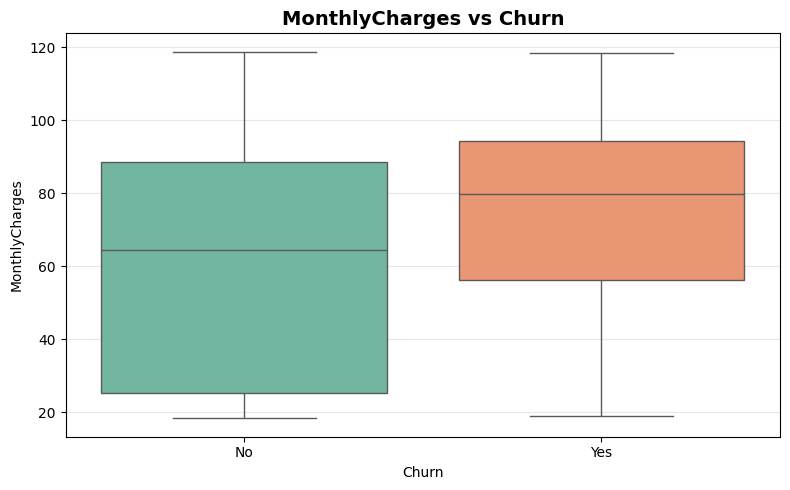



Analysis Completed


NUMERICAL FEATURE VS CHURN : TOTALCHARGES


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.34,2329.46,18.80,577.83,1683.60,4264.12,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


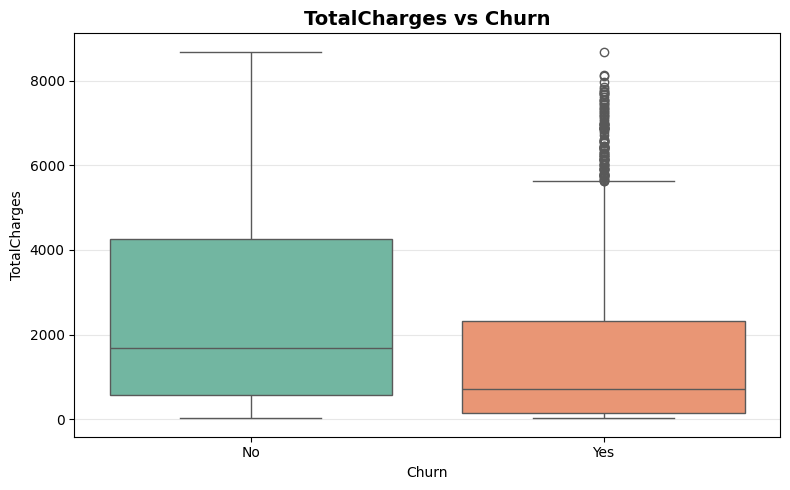



Analysis Completed


In [9]:
for column in numerical_features:
    analyze_numerical_vs_target(df, column)

## Part B: Categorical Features vs Churn

This section examines the relationship between categorical features and the target variable (`Churn`).

For each categorical feature, we compare the distribution of customers who churned and those who did not using summary tables and visualizations.

The objective is to identify categories that exhibit higher or lower churn rates and uncover potential business insights.

### Helper Function 1: Churn Distribution Table

This helper function displays the count and percentage distribution of the target variable within each category of a categorical feature.

The resulting table helps identify categories with relatively higher or lower churn rates.

In [13]:
# Helper Function - 1

def display_churn_distribution(df, column, target="Churn"):
    """
    Display the count and percentage distribution
    of the target variable for each category.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Categorical feature name.

    target : str, default="Churn"
        Target variable.
    """

    churn_distribution = pd.crosstab(
        df[column],
        df[target],
        margins=True
    )

    churn_percentage = pd.crosstab(
        df[column],
        df[target],
        normalize="index"
    ).mul(100).round(2)

    print("Count Distribution")
    display(churn_distribution)

    print("\nPercentage Distribution")
    display(churn_percentage)

### Helper Function 2: Count Plot by Target

This helper function visualizes the distribution of the target variable across the categories of a categorical feature.

The grouped count plot helps compare the number of customers who churned and those who did not within each category.

In [10]:
# Helper Function - 2

def plot_countplot_by_target(df, column, target="Churn"):
    """
    Plot the distribution of the target variable
    across the categories of a categorical feature.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Categorical feature name.

    target : str, default="Churn"
        Target variable.
    """

    plt.figure(figsize=(10, 5))

    ax = sns.countplot(
        data=df,
        x=column,
        hue=target
    )

    plt.title(
        f"{column} vs {target}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(column)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.legend(title=target)

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    plt.show()

### Master Function: Categorical Feature vs Target Analysis

This function performs a complete bivariate analysis of a categorical feature with respect to the target variable.

For each categorical feature, it performs the following analyses:

1. Churn Distribution Table
2. Count Plot by Target

This workflow provides both tabular and visual comparisons to help identify categories associated with higher or lower churn.

In [14]:
# Master Function for Categorical Feature v/s Target Analysis

def analyze_categorical_vs_target(df, column, target="Churn"):
    """
    Perform a complete bivariate analysis of a categorical
    feature against the target variable.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Categorical feature name.

    target : str, default="Churn"
        Target variable.
    """

    if column not in df.columns:
        raise ValueError(f"'{column}' is not a valid column in the DataFrame.")

    if target not in df.columns:
        raise ValueError(f"'{target}' is not a valid column in the DataFrame.")

    if pd.api.types.is_numeric_dtype(df[column]):
        raise TypeError(f"'{column}' is not a categorical feature.")

    print("\n")
    print("=" * 80)
    print(f"CATEGORICAL FEATURE VS {target.upper()} : {column.upper()}")
    print("=" * 80)

    display_churn_distribution(df, column, target)
    print("\n")

    plot_countplot_by_target(df, column, target)

    print("\n")
    print("=" * 80)
    print("Analysis Completed")
    print("=" * 80)



CATEGORICAL FEATURE VS CHURN : CONTRACT
Count Distribution


Churn,No,Yes,All
Contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043



Percentage Distribution


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


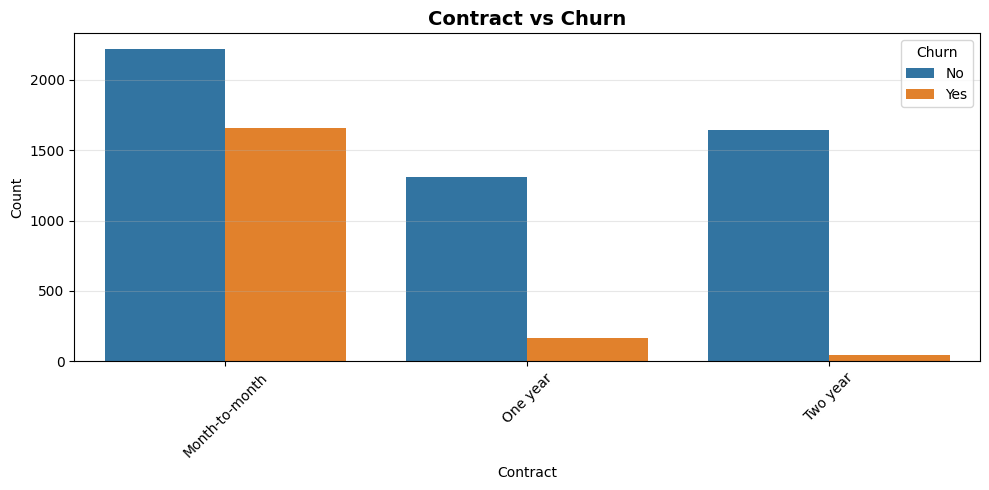



Analysis Completed


In [15]:
analyze_categorical_vs_target(df, "Contract")